Saving Student Depression Dataset .csv to Student Depression Dataset  (1).csv


<ipython-input-1-309887861be5>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


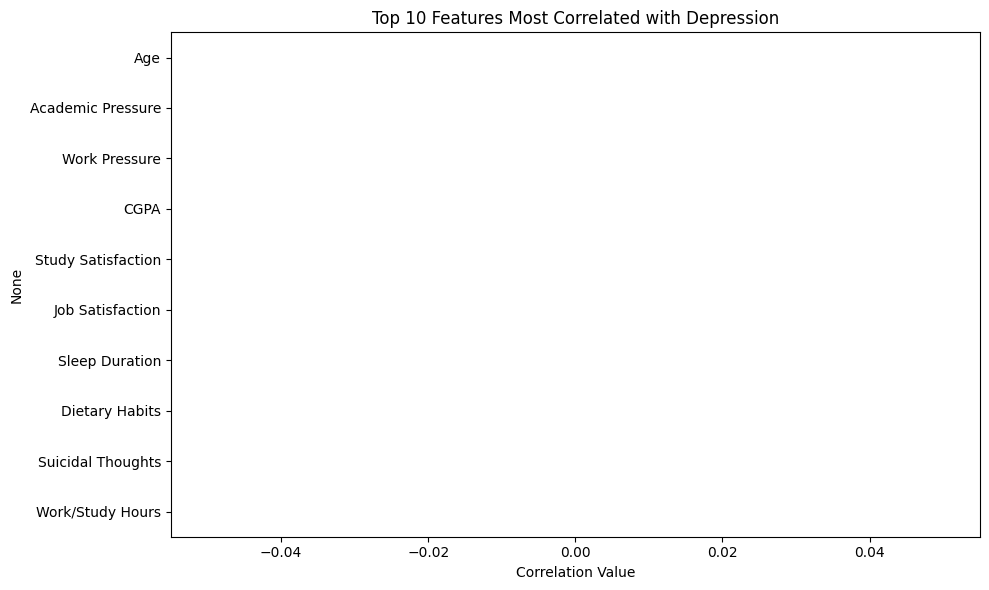

In [1]:
# Step 1: Upload the CSV file
from google.colab import files
uploaded = files.upload()

# Step 2: Import required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Load the dataset (auto-detect uploaded file name)
filename = next(iter(uploaded))
df = pd.read_csv(filename)

# Step 4: Rename columns for easier access
df.rename(columns={
    'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts',
    'Family History of Mental Illness': 'Family History',
}, inplace=True)

# Step 5: Convert Yes/No columns to 1/0
df['Depression'] = df['Depression'].map({'Yes': 1, 'No': 0})
df['Suicidal Thoughts'] = df['Suicidal Thoughts'].map({'Yes': 1, 'No': 0})
df['Family History'] = df['Family History'].map({'Yes': 1, 'No': 0})

# Step 6: Encode Sleep Duration and Dietary Habits
df['Sleep Duration'] = df['Sleep Duration'].map({
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3
})
df['Dietary Habits'] = df['Dietary Habits'].map({
    'Unhealthy': 1,
    'Moderate': 2,
    'Healthy': 3
})

# Step 7: Drop 'id' column if exists
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

# Step 8: One-hot encode other categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 9: Compute correlation matrix
correlation_matrix = df_encoded.corr()

# Step 10: Show top 10 correlations with Depression
top_corr = correlation_matrix['Depression'].drop('Depression').sort_values(ascending=False).head(10)

# Step 11: Plot the top correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Top 10 Features Most Correlated with Depression")
plt.xlabel("Correlation Value")
plt.tight_layout()
plt.show()


Saving Student Depression Dataset .csv to Student Depression Dataset  (2).csv


<ipython-input-2-7e444776a319>:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


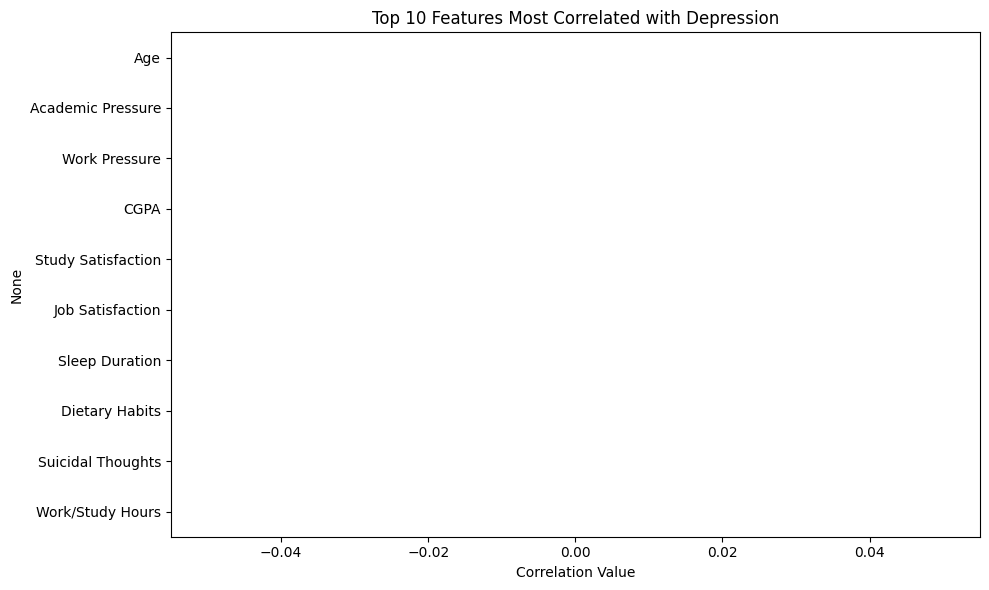

In [2]:
# STEP 1: Upload the dataset
from google.colab import files
uploaded = files.upload()

# STEP 2: Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 3: Load the CSV
filename = next(iter(uploaded))  # get uploaded filename
df = pd.read_csv(filename)

# STEP 4: Strip whitespace from column names to avoid mismatch
df.columns = df.columns.str.strip()

# STEP 5: Rename for simplicity (exact match based on dataset)
df.rename(columns={
    'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts',
    'Family History of Mental Illness': 'Family History'
}, inplace=True)

# STEP 6: Strip string data and map Yes/No to 1/0 (robust against extra spaces)
for col in ['Depression', 'Suicidal Thoughts', 'Family History']:
    df[col] = df[col].astype(str).str.strip().map({'Yes': 1, 'No': 0})

# STEP 7: Map ordinal values (Sleep and Diet)
df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.strip().map({
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3
})
df['Dietary Habits'] = df['Dietary Habits'].astype(str).str.strip().map({
    'Unhealthy': 1,
    'Moderate': 2,
    'Healthy': 3
})

# STEP 8: Drop 'id' column if it exists
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

# STEP 9: Drop rows with any missing values (due to invalid maps)
df.dropna(inplace=True)

# STEP 10: Encode remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# STEP 11: Compute correlation matrix
correlation_matrix = df_encoded.corr()

# STEP 12: Extract top 10 features correlated with Depression
top_corr = correlation_matrix['Depression'].drop('Depression').sort_values(key=abs, ascending=False).head(10)

# STEP 13: Plot results
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Top 10 Features Most Correlated with Depression")
plt.xlabel("Correlation Value")
plt.tight_layout()
plt.show()


In [3]:
# Check unique values in the key columns
print("Unique values in 'Depression':", df['Depression'].unique())
print("Unique values in 'Suicidal Thoughts':", df['Suicidal Thoughts'].unique())
print("First 5 rows:")
print(df[['Depression', 'Suicidal Thoughts', 'Academic Pressure', 'Sleep Duration', 'Dietary Habits']].head())


Unique values in 'Depression': []
Unique values in 'Suicidal Thoughts': []
First 5 rows:
Empty DataFrame
Columns: [Depression, Suicidal Thoughts, Academic Pressure, Sleep Duration, Dietary Habits]
Index: []


In [4]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

filename = next(iter(uploaded))
df = pd.read_csv(filename)

# Clean column names
df.columns = df.columns.str.strip()

# Print column names
print("Columns:", df.columns.tolist())

# Print raw unique values of Depression column
print("Raw unique values in 'Depression':", df['Depression'].unique())

# Clean and map
df['Depression'] = df['Depression'].astype(str).str.strip().map({'Yes': 1, 'No': 0})
print("Mapped unique values in 'Depression':", df['Depression'].unique())

# Continue only if mapping worked
if df['Depression'].isna().all():
    print("❌ Mapping failed. Column contains NaN only.")
else:
    df['Suicidal Thoughts'] = df['Have you ever had suicidal thoughts ?'].astype(str).str.strip().map({'Yes': 1, 'No': 0})
    df['Family History'] = df['Family History of Mental Illness'].astype(str).str.strip().map({'Yes': 1, 'No': 0})
    df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.strip().map({
        'Less than 5 hours': 1,
        '5-6 hours': 2,
        '7-8 hours': 3
    })
    df['Dietary Habits'] = df['Dietary Habits'].astype(str).str.strip().map({
        'Unhealthy': 1,
        'Moderate': 2,
        'Healthy': 3
    })

    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)

    df.dropna(inplace=True)

    df_encoded = pd.get_dummies(df, drop_first=True)
    corr_matrix = df_encoded.corr()

    top_corr = corr_matrix['Depression'].drop('Depression').sort_values(key=abs, ascending=False).head(10)

    print("\nTop 10 correlations with Depression:")
    print(top_corr)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
    plt.title("Top 10 Features Most Correlated with Depression")
    plt.xlabel("Correlation Value")
    plt.tight_layout()
    plt.show()


Saving Student Depression Dataset .csv to Student Depression Dataset  (3).csv
Columns: ['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']
Raw unique values in 'Depression': [1 0]
Mapped unique values in 'Depression': [nan]
❌ Mapping failed. Column contains NaN only.


Saving Student Depression Dataset .csv to Student Depression Dataset  (4).csv


<ipython-input-5-93879e869d05>:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


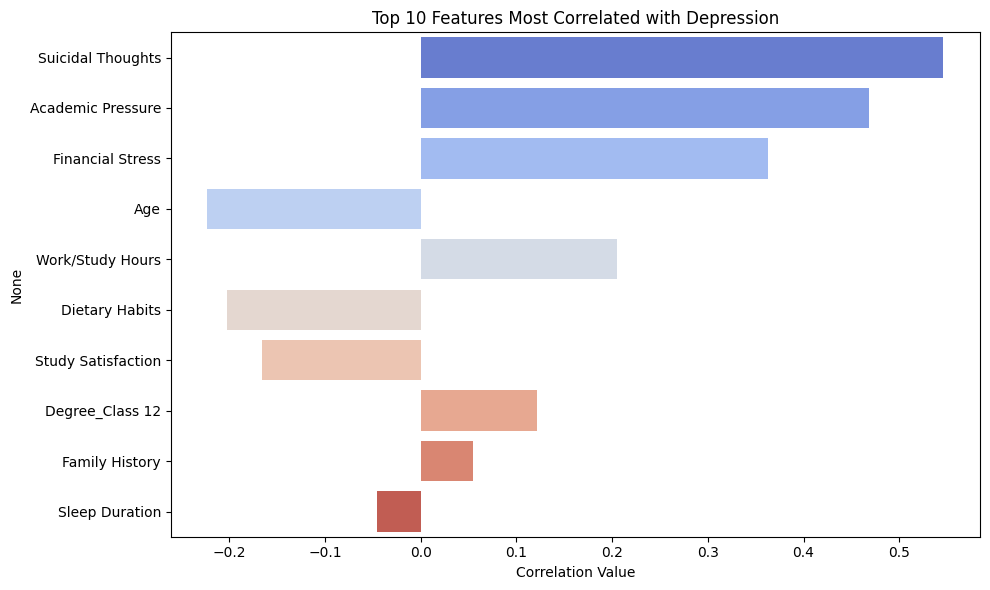

In [5]:
# Step 1: Upload your file
from google.colab import files
uploaded = files.upload()

# Step 2: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Load the CSV file
filename = next(iter(uploaded))
df = pd.read_csv(filename)

# Step 4: Clean column names (remove trailing spaces)
df.columns = df.columns.str.strip()

# Step 5: Rename columns for easier access
df.rename(columns={
    'Have you ever had suicidal thoughts ?': 'Suicidal Thoughts',
    'Family History of Mental Illness': 'Family History'
}, inplace=True)

# ✅ Step 6: DO NOT TOUCH 'Depression' (already 0/1)
# Only map other binary columns
df['Suicidal Thoughts'] = df['Suicidal Thoughts'].astype(str).str.strip().map({'Yes': 1, 'No': 0})
df['Family History'] = df['Family History'].astype(str).str.strip().map({'Yes': 1, 'No': 0})

# Step 7: Map ordinal columns
df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.strip().map({
    'Less than 5 hours': 1,
    '5-6 hours': 2,
    '7-8 hours': 3
})
df['Dietary Habits'] = df['Dietary Habits'].astype(str).str.strip().map({
    'Unhealthy': 1,
    'Moderate': 2,
    'Healthy': 3
})

# Step 8: Drop 'id' column if exists
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

# Step 9: Drop rows with any missing values
df.dropna(inplace=True)

# Step 10: One-hot encode remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Step 11: Compute correlation matrix
correlation_matrix = df_encoded.corr()

# Step 12: Top 10 correlations with Depression
top_corr = correlation_matrix['Depression'].drop('Depression').sort_values(key=abs, ascending=False).head(10)

# Step 13: Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title("Top 10 Features Most Correlated with Depression")
plt.xlabel("Correlation Value")
plt.tight_layout()
plt.show()
